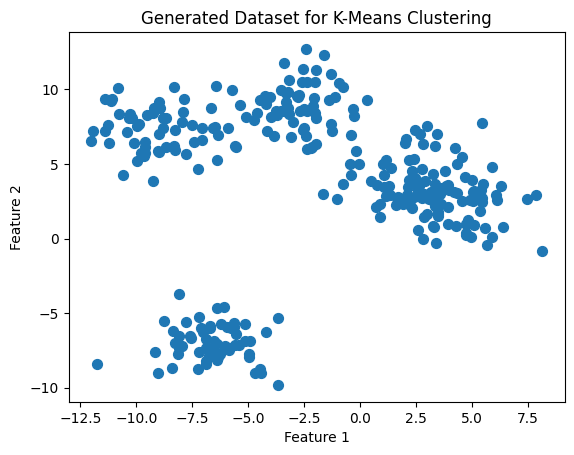

In [18]:
#Creating a toy dataset with 5 Clusters with make_blobs
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
# Parameters
n_samples = 300
n_features = 2
centers = 5
# Generate data
x, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=centers, cluster_std=1.5, random_state=42)
# * Visualize the data
plt.scatter(x[:, 0], x[:, 1], s=50)
plt.title("Generated Dataset for K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

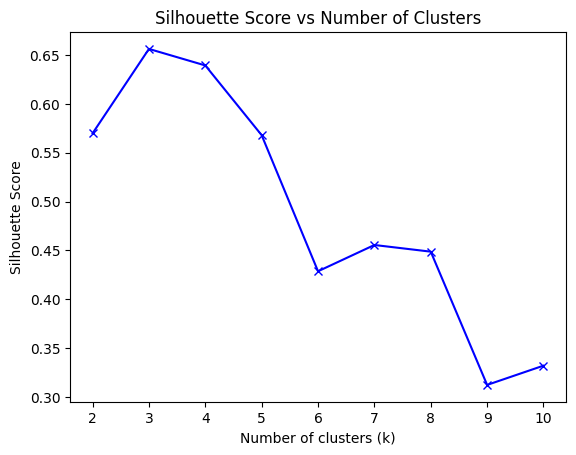

In [19]:
#Fitting KMeans and plotting graph of number of clusters vs silhouette score to find the optimal number of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
silhouette_scores = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(x)
    y_kmeans = kmeans.predict(x)
    score = silhouette_score(x, y_kmeans)
    silhouette_scores.append(score)
#Plotting the silhouette scores
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

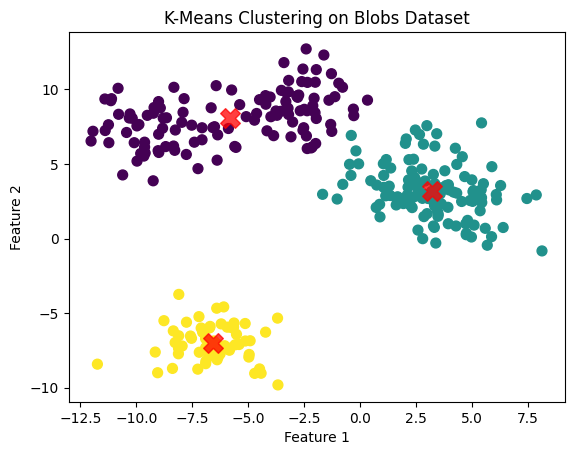

In [20]:
#Plotting the clusters with centroids for k =3
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
#Plotting the clustered data with centroids 
y_kmeans = kmeans.predict(x)
plt.scatter(x[:, 0], x[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title("K-Means Clustering on Blobs Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

For n_clusters = 2, the average silhouette_score is : 0.4456610321988083


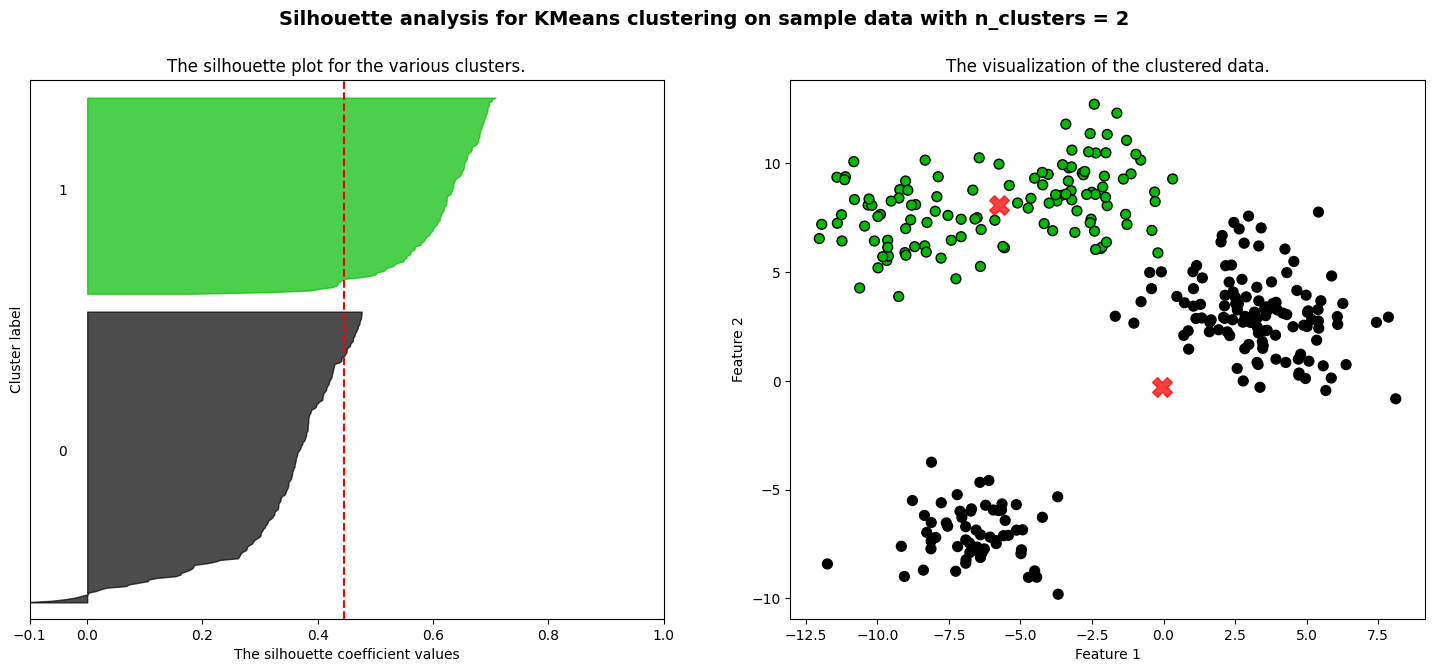

For n_clusters = 3, the average silhouette_score is : 0.6563766362506921


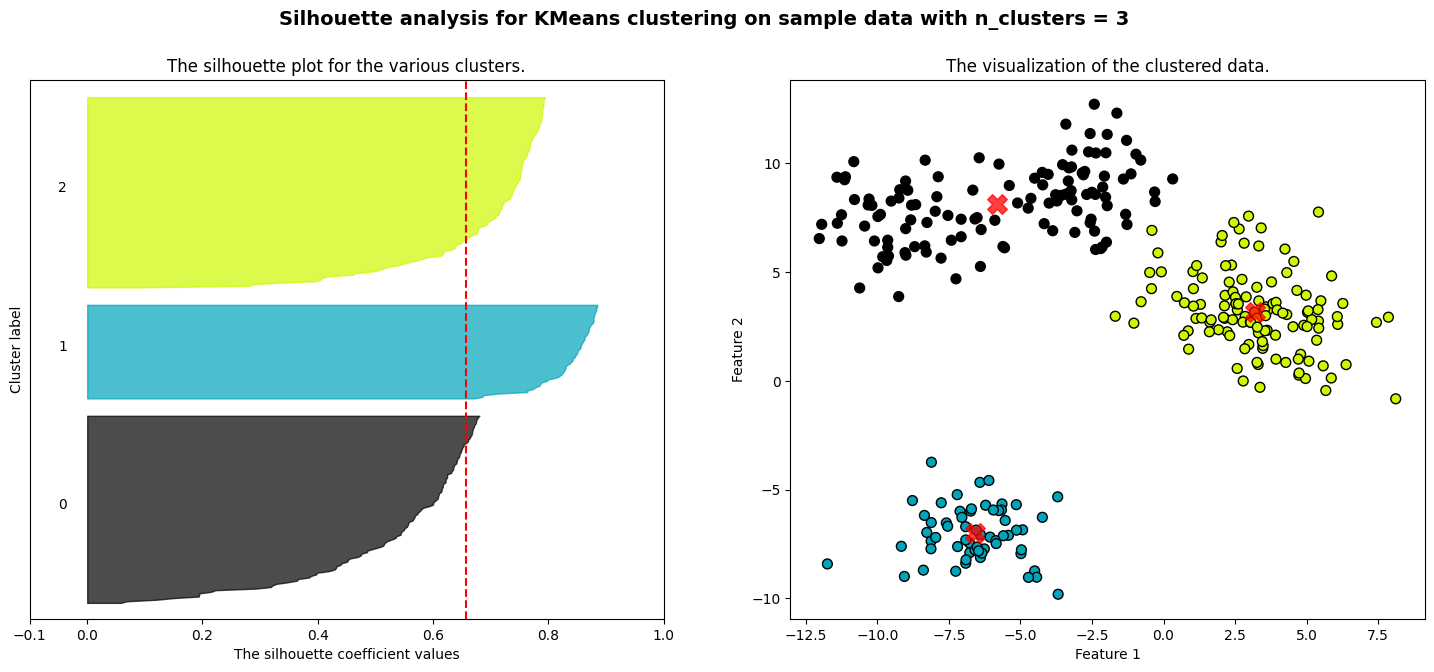

For n_clusters = 4, the average silhouette_score is : 0.6394449341146701


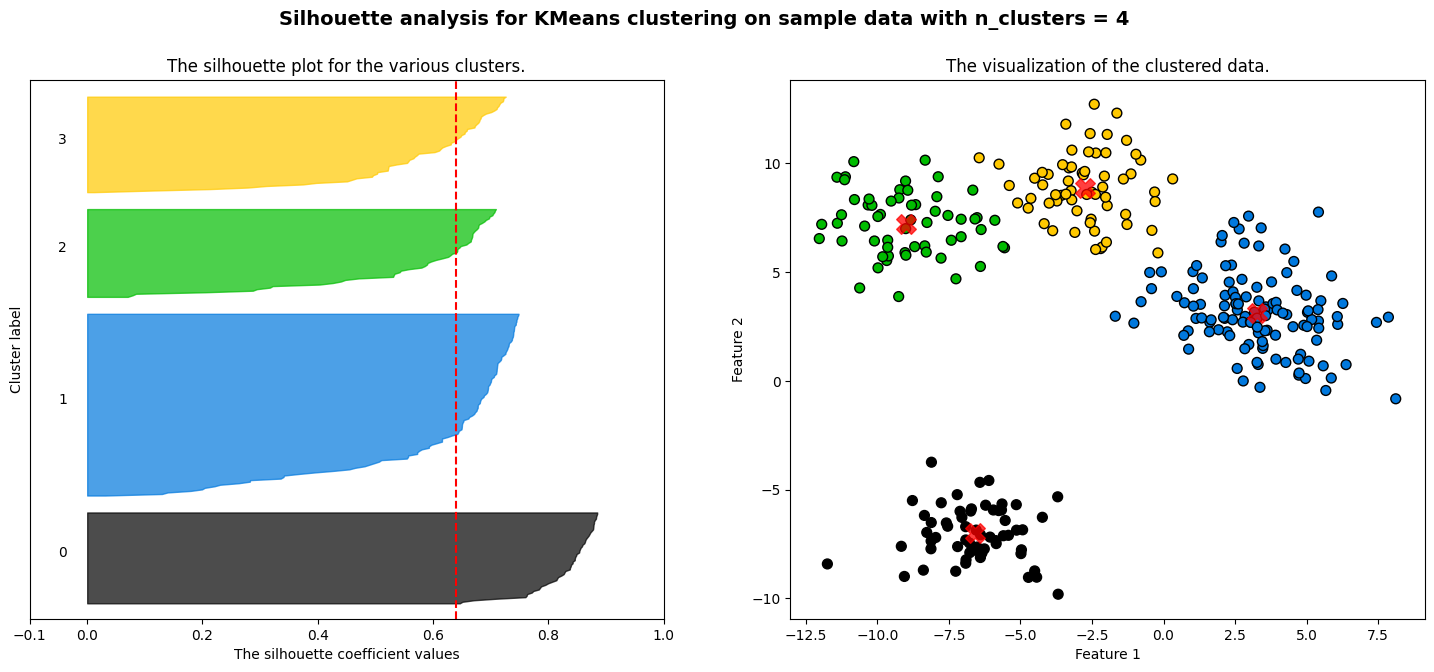

For n_clusters = 5, the average silhouette_score is : 0.5303892993033685


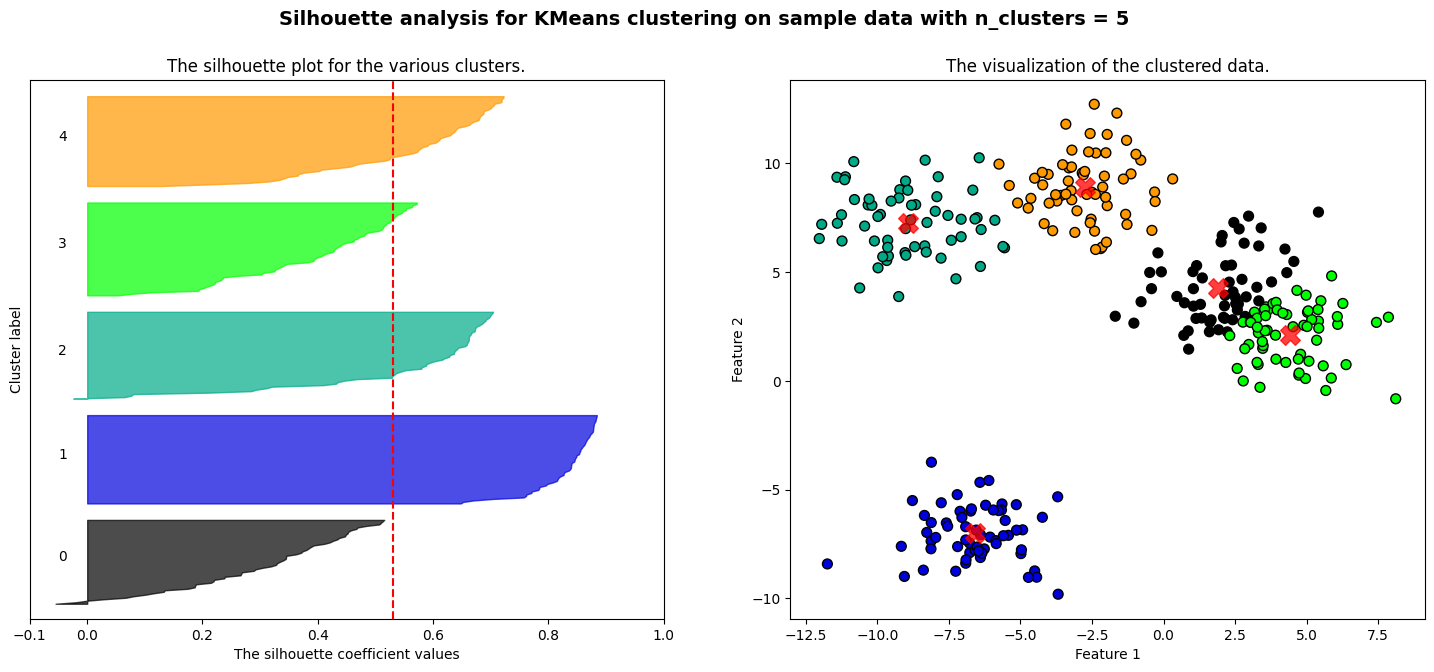

For n_clusters = 6, the average silhouette_score is : 0.4806753439660433


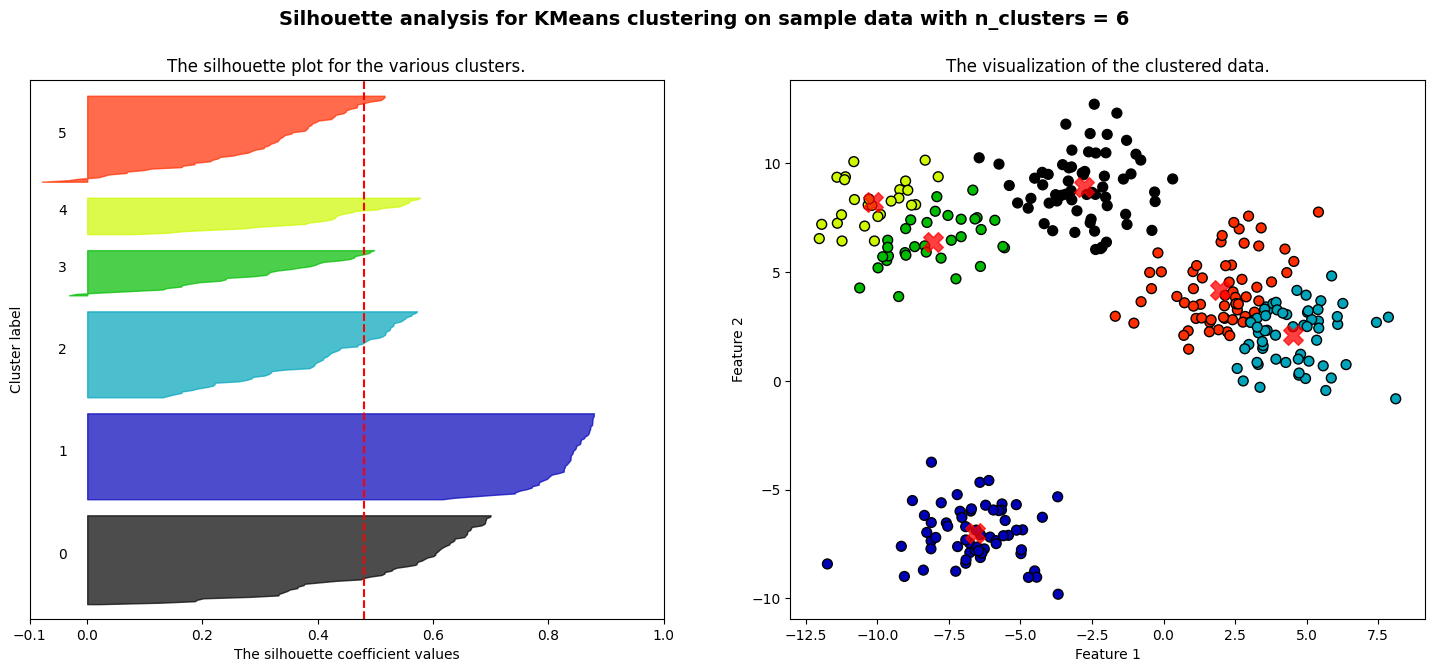

For n_clusters = 7, the average silhouette_score is : 0.4342512112098734


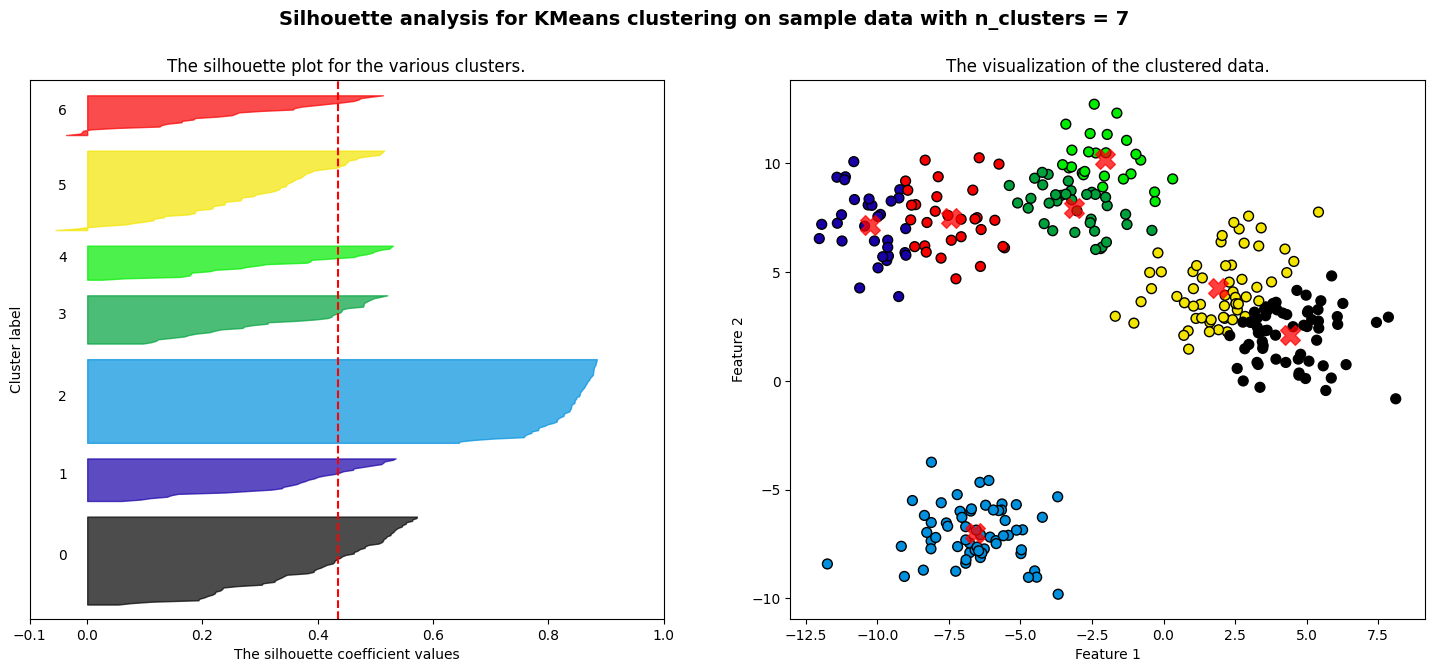

For n_clusters = 8, the average silhouette_score is : 0.3948147218527044


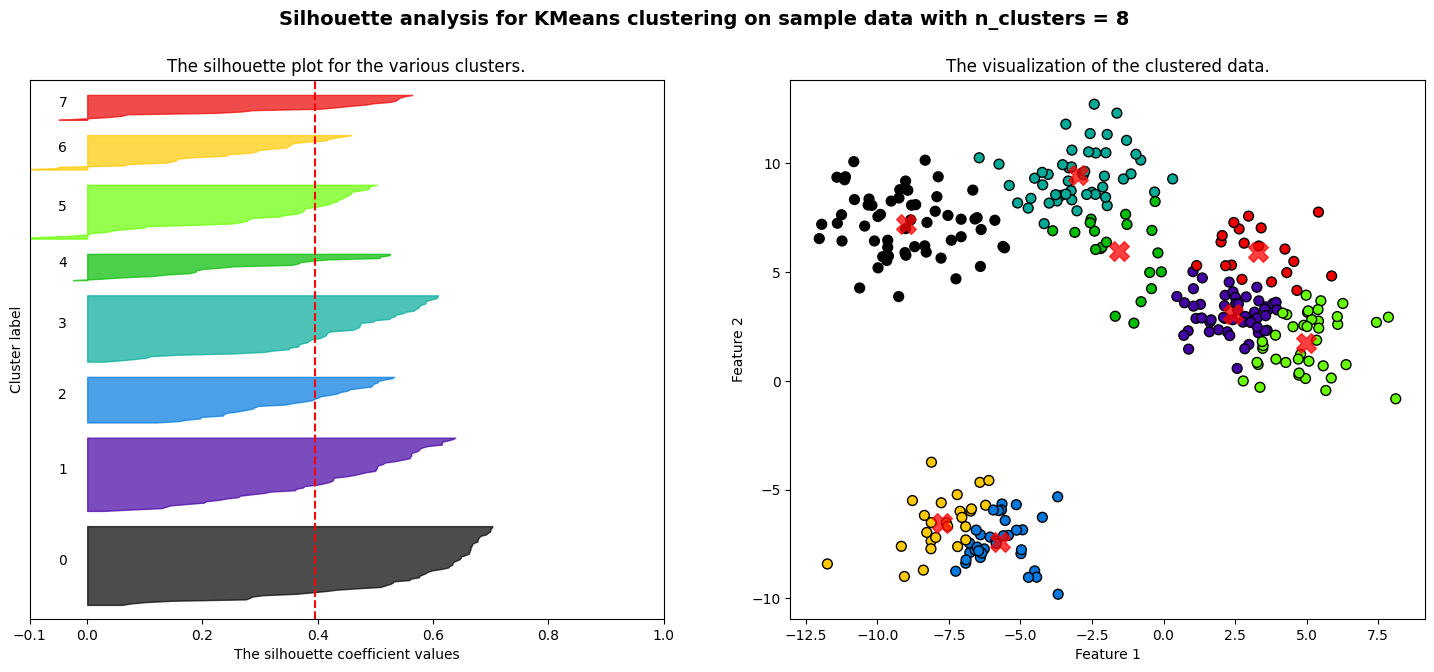

For n_clusters = 9, the average silhouette_score is : 0.3389162360813912


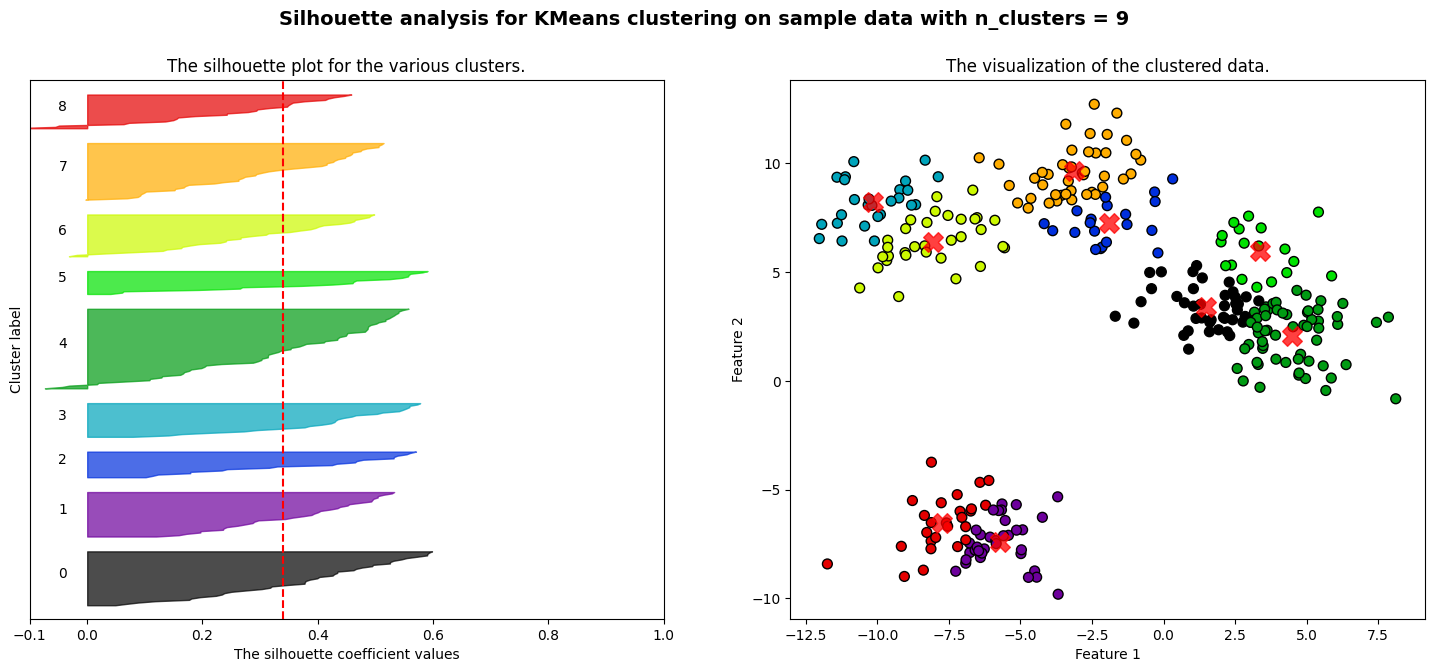

For n_clusters = 10, the average silhouette_score is : 0.3756673809463508


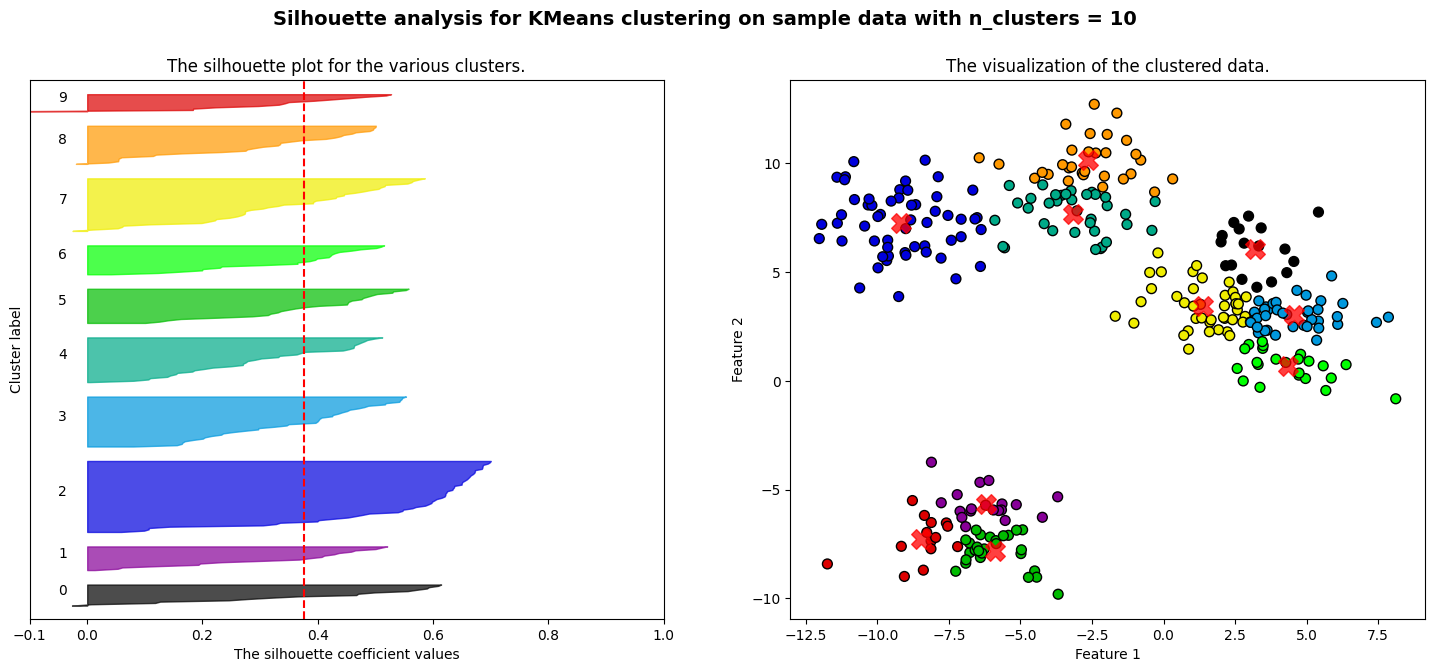

In [21]:
#Plotting Silhouttee plot for all the K values along with clustered data
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
for n_clusters in range(2, 11):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)
    # The 1st subplot is the silhouette plot
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(x) + (n_clusters + 1) * 10])
    # Initialize the KMeans clusterer
    clusterer = KMeans(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(x)
    # The silhouette score
    silhouette_avg = silhouette_score(x, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(x, cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples
    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(x[:, 0], x[:, 1], marker='o', s=50, c=colors, edgecolor='k')
    # Draw the centroids of the clusters
    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='X', c='red', s=200, alpha=0.75)
    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")
    plt.suptitle((f"Silhouette analysis for KMeans clustering on sample data "
                  f"with n_clusters = {n_clusters}"), fontsize=14, fontweight='bold')
    plt.show()